# Evaluacion del modelo de churn (3 meses)

Evaluacion rigurosa del modelo 1: prediccion de churn a 3 meses.

**Contenido:**
1. Datos y feature selection
2. Analisis de leakage en features de month3
3. Comparativa de ventanas temporales
4. Split y justificacion
5. Comparativa de modelos (train vs test)
6. Cross-validation con intervalos de confianza
7. Tuning + Learning curves
8. Feature importance y variable selection
9. Threshold optimo
10. Rendimiento por segmento
11. Perfiles de riesgo
12. Analisis de precio vs churn
13. Performance temporal (walk-forward)
14. Metrica de negocio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from scipy.stats import uniform, randint

## 1. Datos y feature selection

In [2]:
df = pd.read_parquet("../data/df_3m_churn.parquet", engine="pyarrow")
print(f"Dataset: {df.shape[0]} contratos, {df.shape[1]} columnas")
print(f"\nTarget (churned_3m):")
print(f"  No churn: {(df['churned_3m']==False).sum()} ({(df['churned_3m']==False).mean():.1%})")
print(f"  Churn:    {(df['churned_3m']==True).sum()} ({(df['churned_3m']==True).mean():.1%})")

Dataset: 3733 contratos, 128 columnas

Target (churned_3m):
  No churn: 3503 (93.8%)
  Churn:    230 (6.2%)


In [3]:
# Columnas excluidas:
# - Identificadores y metadata: advertiser_zrive_id, contract_start_date, contract_end_period, etc.
# - Target: churned_3m
# - Leakage post-onboarding: stable_price*, invoice_post_*, n_months_post_onboarding
# - Leakage temporal: features de month3 (ver seccion 2)

NON_FEATURE_COLS = [
    "churned_3m", "advertiser_zrive_id", "contract_start_date",
    "contract_end_period", "contrato_churn_date", "contract_duration_months",
    "advertiser_group_id", "advertiser_province", "is_right_censored", "province_id"
]

post_onboarding_cols = [
    c for c in df.columns
    if c.startswith("invoice_post_") or c.startswith("stable_price") or c == "n_months_post_onboarding"
]

month3_cols = [c for c in df.columns if "month3" in c]

exclude = set(NON_FEATURE_COLS + post_onboarding_cols + month3_cols)
feature_cols = [c for c in df.columns if c not in exclude]

print(f"Features seleccionadas: {len(feature_cols)}")
print(f"Excluidas: {len(exclude)} columnas")
print(f"  - Identificadores/metadata: {len(NON_FEATURE_COLS)}")
print(f"  - Post-onboarding (leakage): {len(post_onboarding_cols)}")
print(f"  - Month3 (leakage temporal): {len(month3_cols)}")

Features seleccionadas: 72
Excluidas: 56 columnas
  - Identificadores/metadata: 10
  - Post-onboarding (leakage): 30
  - Month3 (leakage temporal): 17


## 2. Analisis de leakage en features de month3

El target `churned_3m` indica si un contrato duro exactamente 3 meses (churn) o mas (no churn).
Esto significa que para todos los contratos que churnan, el mes 3 es su ultimo mes de actividad.

Si la actividad del mes 3 ya refleja el proceso de abandono (ads que bajan a 0, etc.),
el modelo estaria usando la consecuencia del churn para predecir el churn. Eso es leakage.

In [4]:
churned = df[df["churned_3m"] == True]
not_churned = df[df["churned_3m"] == False]

print("Duracion de los contratos churned:")
print(f"  min={churned['contract_duration_months'].min()}, "
      f"max={churned['contract_duration_months'].max()}, "
      f"mean={churned['contract_duration_months'].mean():.1f}")
print(f"  -> 100% de los churned tienen exactamente 3 meses")
print(f"\nEl mes 3 ES el ultimo mes para todos los contratos churned.")

print(f"\npublished_ads_month3 == 0:")
print(f"  Churn:    {(churned['monthly_published_ads_month3']==0).mean():.1%}")
print(f"  No churn: {(not_churned['monthly_published_ads_month3']==0).mean():.1%}")

# Tabla con percentiles (no solo media)
print(f"\nActividad en month3 por percentiles:")
print(f"{'Metrica':<30} {'Grupo':<10} {'p25':>8} {'p50':>8} {'p75':>8} {'mean':>8}")
print("-" * 72)
for metric in ["monthly_published_ads", "monthly_total_invoice", "monthly_leads"]:
    col = f"{metric}_month3"
    for label, subset in [("Churn", churned), ("No churn", not_churned)]:
        vals = subset[col]
        print(f"{metric:<30} {label:<10} {vals.quantile(0.25):>8.1f} {vals.quantile(0.5):>8.1f} {vals.quantile(0.75):>8.1f} {vals.mean():>8.1f}")


Duracion de los contratos churned:
  min=3, max=3, mean=3.0
  -> 100% de los churned tienen exactamente 3 meses

El mes 3 ES el ultimo mes para todos los contratos churned.

published_ads_month3 == 0:
  Churn:    30.0%
  No churn: 7.1%

Actividad en month3 por percentiles:
Metrica                        Grupo           p25      p50      p75     mean
------------------------------------------------------------------------
monthly_published_ads          Churn           0.0      3.0      9.0     17.4
monthly_published_ads          No churn        3.0      9.0     26.0     73.9
monthly_total_invoice          Churn          63.3    112.1    173.3    166.4
monthly_total_invoice          No churn       78.3    140.0    263.4    293.9
monthly_leads                  Churn           0.0      3.0     11.0     14.0
monthly_leads                  No churn        1.0      6.0     15.0     14.6


In [5]:
# Ablation: comparar modelo con y sin month3
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score

all_feature_cols = [c for c in df.columns if c not in set(NON_FEATURE_COLS + post_onboarding_cols)]
no_m3_feature_cols = [c for c in all_feature_cols if "month3" not in c]

y = df["churned_3m"].astype(int)
groups = df["advertiser_zrive_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df[all_feature_cols], y, groups))
groups_train = groups.iloc[train_idx]
gkf = GroupKFold(n_splits=5)

scale = (y.iloc[train_idx] == 0).sum() / (y.iloc[train_idx] == 1).sum()
sample_weights = np.where(y.iloc[train_idx] == 1, scale, 1.0)

print(f"{'Config':<25} {'Train AUC':>10} {'CV AUC':>8} {'CV Std':>8} {'Test AUC':>10} {'Test PR-AUC':>12}")
print("=" * 75)

for name, cols in [("Con month3", all_feature_cols), ("Sin month3", no_m3_feature_cols)]:
    X_tr = df[cols].fillna(0).iloc[train_idx]
    X_te = df[cols].fillna(0).iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    gb = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
    gb.fit(X_tr, y_tr, sample_weight=sample_weights)

    train_auc = roc_auc_score(y_tr, gb.predict_proba(X_tr)[:, 1])
    scores = cross_val_score(gb, X_tr, y_tr, cv=gkf, groups=groups_train, scoring="roc_auc", n_jobs=-1)
    y_proba = gb.predict_proba(X_te)[:, 1]

    print(f"{name:<25} {train_auc:>10.3f} {scores.mean():>8.3f} {scores.std():>8.3f} "
          f"{roc_auc_score(y_te, y_proba):>10.3f} {average_precision_score(y_te, y_proba):>12.3f}")

print(f"\nConclucion: excluimos features de month3 para evitar leakage temporal.")
print(f"El modelo pierde algo de ROC AUC pero la PR-AUC se mantiene.")


Config                     Train AUC   CV AUC   CV Std   Test AUC  Test PR-AUC


Con month3                     1.000    0.775    0.037      0.652        0.207


Sin month3                     1.000    0.768    0.056      0.631        0.214

Conclucion: excluimos features de month3 para evitar leakage temporal.
El modelo pierde algo de ROC AUC pero la PR-AUC se mantiene.


## 2b. Comparativa de ventanas temporales (n_months)

El pipeline permite definir el horizonte de churn. Comparamos 3, 4 y 5 meses
para ver como cambia el churn rate y el rendimiento del modelo.
En cada caso excluimos las features del ultimo mes (mismo criterio de leakage).

In [6]:
# Resultados pre-computados corriendo el pipeline con n_months=3,4,5
# y excluyendo features del ultimo mes en cada caso (mismo criterio de leakage)
# Modelo: HistGradientBoosting, 5-fold GroupKFold por advertiser

results_nmonths = pd.DataFrame({
    'n_months': [3, 4, 5],
    'Contratos': [3733, 3367, 2944],
    'Churn': [230, 338, 384],
    'Churn_pct': [6.2, 10.0, 13.0],
    'Features': [72, 88, 103],
    'CV_AUC': [0.717, 0.704, 0.727],
    'CV_Std': [0.031, 0.021, 0.016],
    'CV_PR_AUC': [0.194, 0.217, 0.336],
})

print(f"{'n_months':>8} {'Contratos':>10} {'Churn':>6} {'Churn%':>8} {'Features':>9} {'CV AUC':>8} {'CV Std':>8} {'CV PR-AUC':>10}")
print('=' * 80)
for _, row in results_nmonths.iterrows():
    print(f"{int(row['n_months']):>8} {int(row['Contratos']):>10} {int(row['Churn']):>6} "
          f"{row['Churn_pct']:>7.1f}% {int(row['Features']):>9} "
          f"{row['CV_AUC']:>8.3f} {row['CV_Std']:>8.3f} {row['CV_PR_AUC']:>10.3f}")

print(f'\nA mayor ventana, mas positivos y mejor PR-AUC (0.19 -> 0.34).')
print(f'ROC AUC es similar en los tres (~0.71-0.73).')
print(f'Mantenemos n_months=3 como horizonte principal (prediccion mas temprana).')


n_months  Contratos  Churn   Churn%  Features   CV AUC   CV Std  CV PR-AUC
       3       3733    230     6.2%        72    0.717    0.031      0.194
       4       3367    338    10.0%        88    0.704    0.021      0.217
       5       2944    384    13.0%       103    0.727    0.016      0.336

A mayor ventana, mas positivos y mejor PR-AUC (0.19 -> 0.34).
ROC AUC es similar en los tres (~0.71-0.73).
Mantenemos n_months=3 como horizonte principal (prediccion mas temprana).


## 3. Split por advertiser

Un mismo advertiser puede tener varios contratos. Si un contrato cae en train y otro
en test, hay leakage por advertiser (el modelo aprende patrones del advertiser, no del contrato).

Usamos `GroupShuffleSplit` para garantizar 0% de overlap entre advertisers de train y test.

In [7]:
X = df[feature_cols].fillna(0)
y = df["churned_3m"].astype(int)
groups = df["advertiser_zrive_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

train_advs = set(groups.iloc[train_idx])
test_advs = set(groups.iloc[test_idx])

print(f"Train: {len(X_train)} contratos, {len(train_advs)} advertisers")
print(f"Test:  {len(X_test)} contratos, {len(test_advs)} advertisers")
print(f"Overlap advertisers: {len(train_advs & test_advs)}")
print(f"\nChurn rate train: {y_train.mean():.1%}")
print(f"Churn rate test:  {y_test.mean():.1%}")

Train: 2983 contratos, 2868 advertisers
Test:  750 contratos, 718 advertisers
Overlap advertisers: 0

Churn rate train: 6.0%
Churn rate test:  6.8%


## 4. Comparativa de modelos (train vs test)

Entrenamos varios modelos y comparamos su rendimiento en train y test para
detectar overfitting. Usamos ROC AUC y PR AUC (mas informativa con desbalanceo).

In [8]:
# Sample weights para compensar desbalanceo en modelos de boosting
scale = (y_train == 0).sum() / (y_train == 1).sum()
sample_weights = np.where(y_train == 1, scale, 1.0)

# Entrenar modelos
models = {}

models["Baseline"] = DummyClassifier(strategy="most_frequent")
models["Baseline"].fit(X_train, y_train)

models["Logistic Regression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
models["Logistic Regression"].fit(X_train, y_train)

models["Random Forest"] = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)
models["Random Forest"].fit(X_train, y_train)

models["Gradient Boosting"] = HistGradientBoostingClassifier(
    max_iter=200, max_depth=5, learning_rate=0.1, random_state=42
)
models["Gradient Boosting"].fit(X_train, y_train, sample_weight=sample_weights)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtype

In [9]:
# Comparativa train vs test
print(f"{'Modelo':<25} {'Train AUC':>10} {'Test AUC':>10} {'Diff':>8} {'Test PR-AUC':>12}")
print("=" * 68)

results = {}
for name, model in models.items():
    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_proba_test = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, y_proba_train)
    test_auc = roc_auc_score(y_test, y_proba_test)
    test_pr_auc = average_precision_score(y_test, y_proba_test)

    results[name] = {
        "y_proba": y_proba_test,
        "y_pred": model.predict(X_test),
        "train_auc": train_auc,
        "test_auc": test_auc,
        "test_pr_auc": test_pr_auc,
    }

    diff = train_auc - test_auc
    flag = " !!" if diff > 0.10 else ""
    print(f"{name:<25} {train_auc:>10.3f} {test_auc:>10.3f} {diff:>+8.3f} {test_pr_auc:>12.3f}{flag}")

print(f"\nDiff > 0.10 indica posible overfitting.")
print(f"PR AUC baseline (random): {y_test.mean():.3f} (prevalencia de la clase positiva)")

Modelo                     Train AUC   Test AUC     Diff  Test PR-AUC
Baseline                       0.500      0.500   +0.000        0.068
Logistic Regression            0.795      0.652   +0.143        0.194 !!
Random Forest                  1.000      0.670   +0.330        0.185 !!
Gradient Boosting              1.000      0.631   +0.369        0.214 !!

Diff > 0.10 indica posible overfitting.
PR AUC baseline (random): 0.068 (prevalencia de la clase positiva)


## 5. Cross-validation con intervalos de confianza

5-fold GroupKFold agrupado por advertiser. Reportamos mean +/- std para ROC AUC y PR AUC.

In [10]:
gkf = GroupKFold(n_splits=5)

print(f"{'Modelo':<25} {'ROC AUC (CV)':>15} {'PR AUC (CV)':>15}")
print("=" * 58)

for name, model in models.items():
    if name == "Baseline":
        continue

    roc_scores = cross_val_score(
        model, X_train, y_train, cv=gkf, groups=groups_train,
        scoring="roc_auc", n_jobs=-1
    )
    pr_scores = cross_val_score(
        model, X_train, y_train, cv=gkf, groups=groups_train,
        scoring="average_precision", n_jobs=-1
    )

    print(f"{name:<25} {roc_scores.mean():.3f} +/- {roc_scores.std():.3f}  "
          f"{pr_scores.mean():.3f} +/- {pr_scores.std():.3f}")

Modelo                       ROC AUC (CV)     PR AUC (CV)


Logistic Regression       0.701 +/- 0.046  0.142 +/- 0.024


Random Forest             0.752 +/- 0.053  0.190 +/- 0.072


Gradient Boosting         0.768 +/- 0.056  0.216 +/- 0.037


## 6. Tuning de Gradient Boosting

In [11]:
param_dist = {
    "max_iter": randint(100, 500),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.2),
    "min_samples_leaf": randint(10, 50),
    "max_leaf_nodes": randint(20, 60),
    "l2_regularization": uniform(0, 1),
}

gb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=gkf,
    random_state=42,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train, groups=groups_train, sample_weight=sample_weights)

print(f"Mejor ROC AUC (CV): {gb_search.best_score_:.3f}")
print(f"Params: {gb_search.best_params_}")

# Evaluar en test
y_proba_tuned = gb_search.predict_proba(X_test)[:, 1]
y_pred_tuned = gb_search.predict(X_test)

# Train vs test del tuned
train_auc_tuned = roc_auc_score(y_train, gb_search.predict_proba(X_train)[:, 1])
test_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
test_pr_auc_tuned = average_precision_score(y_test, y_proba_tuned)

print(f"\nGB Tuned:")
print(f"  Train ROC AUC: {train_auc_tuned:.3f}")
print(f"  Test ROC AUC:  {test_auc_tuned:.3f} (diff: {train_auc_tuned - test_auc_tuned:+.3f})")
print(f"  Test PR AUC:   {test_pr_auc_tuned:.3f}")

Mejor ROC AUC (CV): 0.773
Params: {'l2_regularization': np.float64(0.8036720768991145), 'learning_rate': np.float64(0.04731401177720717), 'max_depth': 5, 'max_iter': 227, 'max_leaf_nodes': 47, 'min_samples_leaf': 34}

GB Tuned:
  Train ROC AUC: 0.999
  Test ROC AUC:  0.648 (diff: +0.351)
  Test PR AUC:   0.214


## 7b. Learning curves (logloss vs complejidad)

Para diagnosticar el overfitting, miramos logloss (lo que optimiza el modelo)
en funcion de la complejidad: numero de arboles para GB, profundidad para RF.
Si con poca complejidad ya hay gap train-val, puede haber un problema en los datos.

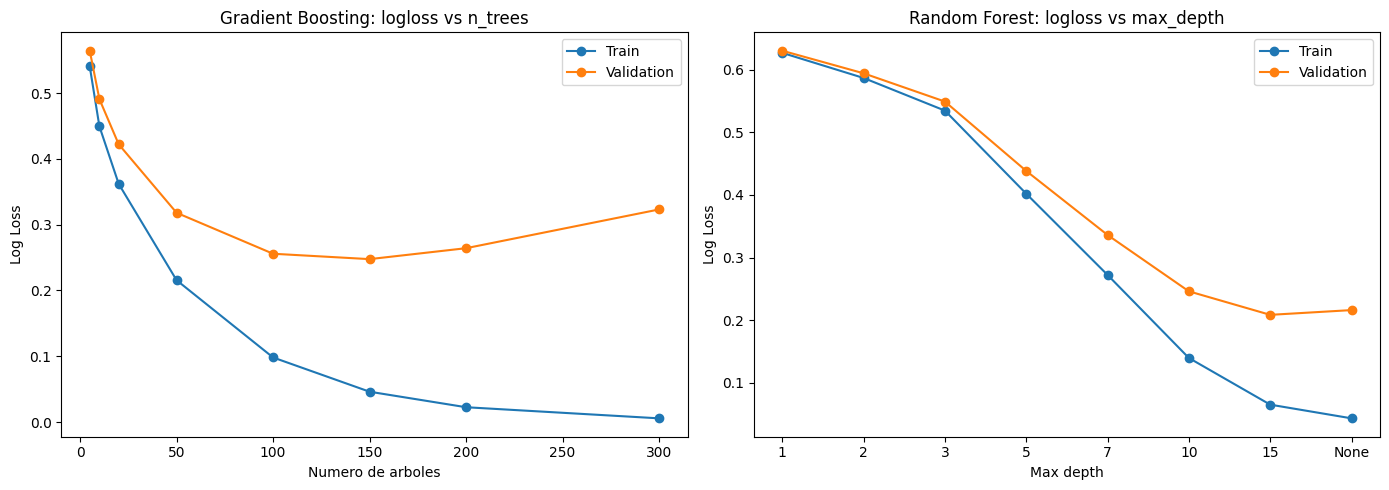

GB: el logloss de validation empieza a subir a partir de ~50 arboles.
RF: el logloss de validation es relativamente estable con la profundidad.


In [12]:
from sklearn.metrics import log_loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GB: logloss vs numero de arboles
n_trees_range = [5, 10, 20, 50, 100, 150, 200, 300]
train_ll, val_ll = [], []

for n_trees in n_trees_range:
    gb_lc = HistGradientBoostingClassifier(
        max_iter=n_trees, max_depth=5, learning_rate=0.1, random_state=42
    )

    fold_train, fold_val = [], []
    for tr, va in gkf.split(X_train, y_train, groups_train):
        sc = (y_train.iloc[tr]==0).sum() / max((y_train.iloc[tr]==1).sum(), 1)
        sw_f = np.where(y_train.iloc[tr]==1, sc, 1.0)
        gb_lc.fit(X_train.iloc[tr], y_train.iloc[tr], sample_weight=sw_f)
        fold_train.append(log_loss(y_train.iloc[tr], gb_lc.predict_proba(X_train.iloc[tr])[:, 1]))
        fold_val.append(log_loss(y_train.iloc[va], gb_lc.predict_proba(X_train.iloc[va])[:, 1]))
    train_ll.append(np.mean(fold_train))
    val_ll.append(np.mean(fold_val))

axes[0].plot(n_trees_range, train_ll, 'o-', label='Train')
axes[0].plot(n_trees_range, val_ll, 'o-', label='Validation')
axes[0].set_xlabel('Numero de arboles')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('Gradient Boosting: logloss vs n_trees')
axes[0].legend()

# RF: logloss vs depth
depth_range = [1, 2, 3, 5, 7, 10, 15, None]
train_ll_rf, val_ll_rf = [], []

for depth in depth_range:
    rf_lc = RandomForestClassifier(
        n_estimators=200, max_depth=depth, class_weight='balanced', random_state=42, n_jobs=-1
    )

    fold_train, fold_val = [], []
    for tr, va in gkf.split(X_train, y_train, groups_train):
        rf_lc.fit(X_train.iloc[tr], y_train.iloc[tr])
        fold_train.append(log_loss(y_train.iloc[tr], rf_lc.predict_proba(X_train.iloc[tr])[:, 1]))
        fold_val.append(log_loss(y_train.iloc[va], rf_lc.predict_proba(X_train.iloc[va])[:, 1]))
    train_ll_rf.append(np.mean(fold_train))
    val_ll_rf.append(np.mean(fold_val))

depth_labels = [str(d) if d else 'None' for d in depth_range]
axes[1].plot(range(len(depth_range)), train_ll_rf, 'o-', label='Train')
axes[1].plot(range(len(depth_range)), val_ll_rf, 'o-', label='Validation')
axes[1].set_xticks(range(len(depth_range)))
axes[1].set_xticklabels(depth_labels)
axes[1].set_xlabel('Max depth')
axes[1].set_ylabel('Log Loss')
axes[1].set_title('Random Forest: logloss vs max_depth')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'GB: el logloss de validation empieza a subir a partir de ~50 arboles.')
print(f'RF: el logloss de validation es relativamente estable con la profundidad.')


## 7. Curvas ROC y Precision-Recall

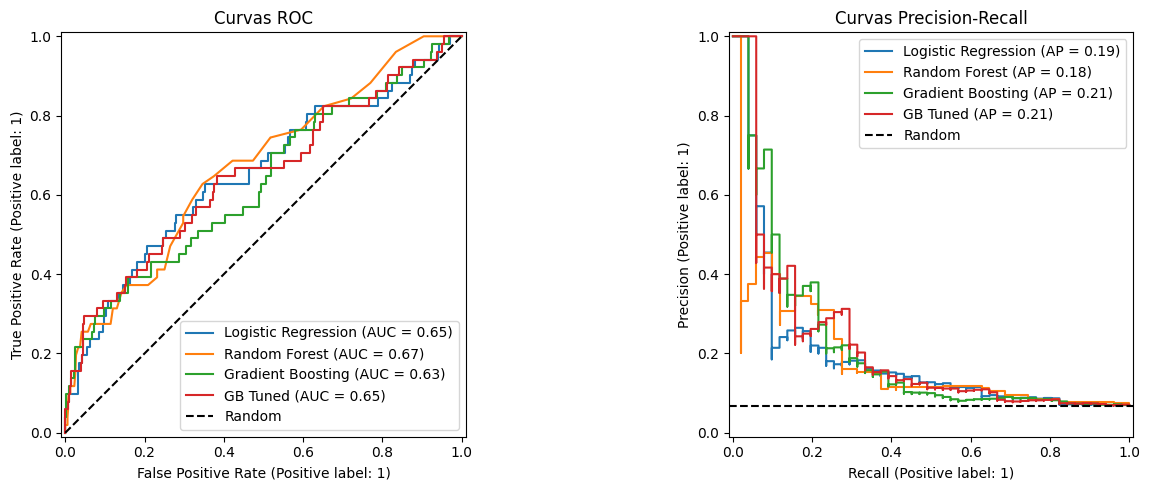

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for name, model in models.items():
    if name == "Baseline":
        continue
    RocCurveDisplay.from_predictions(
        y_test, results[name]["y_proba"], name=name, ax=axes[0]
    )
RocCurveDisplay.from_predictions(
    y_test, y_proba_tuned, name="GB Tuned", ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("Curvas ROC")
axes[0].legend(loc="lower right")

# PR curves
for name, model in models.items():
    if name == "Baseline":
        continue
    PrecisionRecallDisplay.from_predictions(
        y_test, results[name]["y_proba"], name=name, ax=axes[1]
    )
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_tuned, name="GB Tuned", ax=axes[1]
)
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", label="Random")
axes[1].set_title("Curvas Precision-Recall")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

Classification Report (GB Tuned, threshold=0.5):
              precision    recall  f1-score   support

    No churn       0.95      0.94      0.94       699
       Churn       0.26      0.29      0.28        51

    accuracy                           0.89       750
   macro avg       0.60      0.62      0.61       750
weighted avg       0.90      0.89      0.90       750



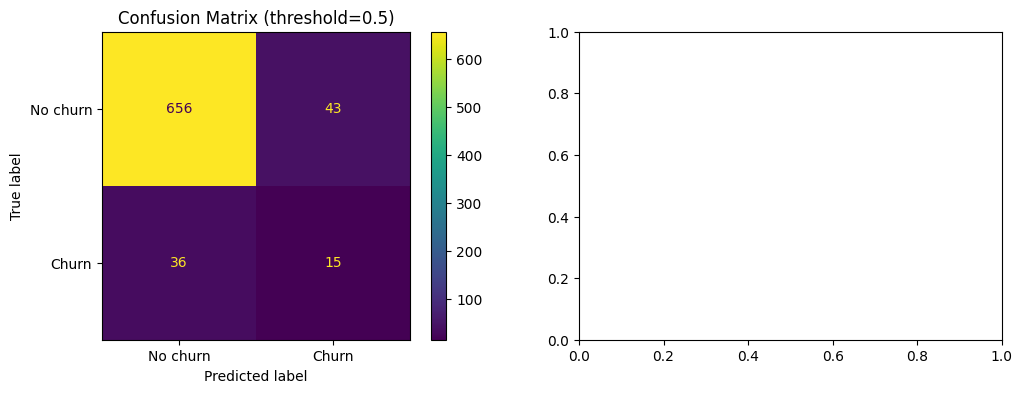

In [14]:
# Confusion matrix del mejor modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=["No churn", "Churn"], ax=axes[0]
)
axes[0].set_title("Confusion Matrix (threshold=0.5)")

# Classification report
print("Classification Report (GB Tuned, threshold=0.5):")
print(classification_report(y_test, y_pred_tuned, target_names=["No churn", "Churn"]))

## 8. Feature importance (permutation)

Permutation importance mide cuanto empeora el modelo al permutar aleatoriamente
cada feature. Es model-agnostic y no tiene los problemas de la importancia nativa
de los arboles (sesgo hacia features con alta cardinalidad).

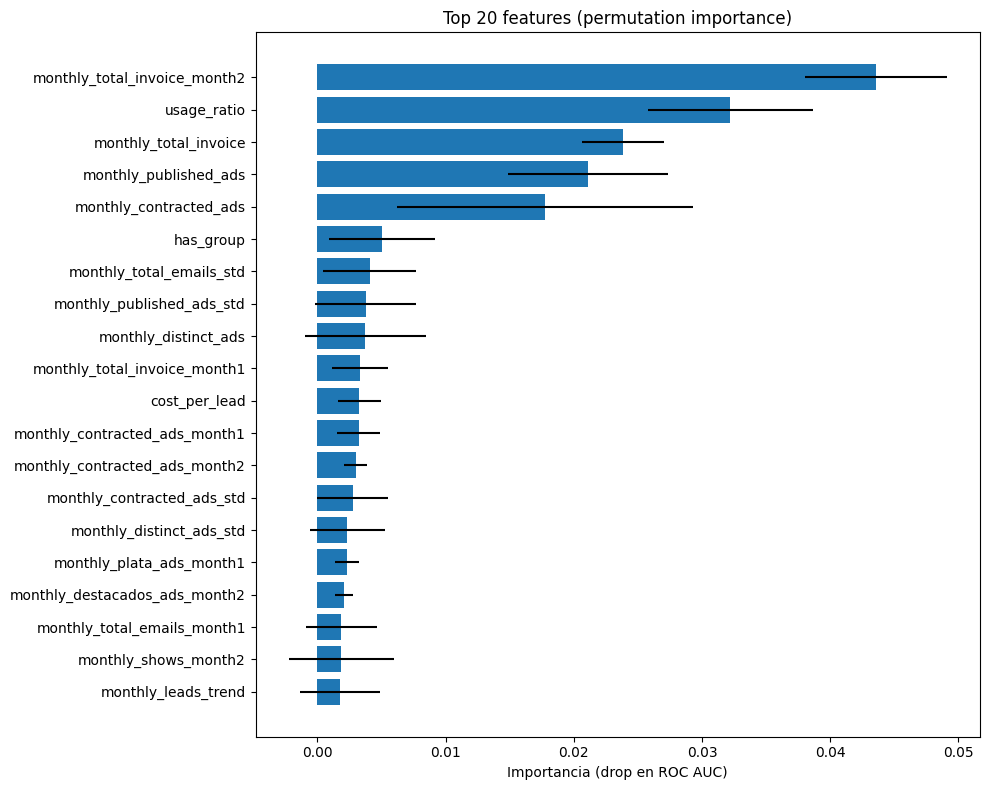

In [15]:
perm_imp = permutation_importance(
    gb_search.best_estimator_, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_imp.importances_mean,
    "importance_std": perm_imp.importances_std,
}).sort_values("importance_mean", ascending=False)

# Top 20
top20 = perm_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    range(len(top20)),
    top20["importance_mean"].values,
    xerr=top20["importance_std"].values,
    align="center"
)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Importancia (drop en ROC AUC)")
ax.set_title("Top 20 features (permutation importance)")
plt.tight_layout()
plt.show()

In [16]:
# Importancia por grupo de features
price_feats = [c for c in feature_cols if "invoice" in c.lower() or "price" in c.lower()]
engagement_feats = [c for c in feature_cols if any(k in c.lower() for k in ["leads", "visits", "shows", "published", "calls"])]
ratio_feats = [c for c in ["usage_ratio", "cost_per_lead", "conversion_rate", "premium_ratio"] if c in feature_cols]

perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols)

print(f"Importancia por grupo:")
print(f"  Facturacion/Precio: {perm_series[price_feats].sum():.4f} ({len(price_feats)} features)")
print(f"  Engagement:         {perm_series[engagement_feats].sum():.4f} ({len(engagement_feats)} features)")
print(f"  Ratios:             {perm_series[ratio_feats].sum():.4f} ({len(ratio_feats)} features)")
print(f"\nSin features de month3, la facturacion tiene mas peso que el engagement.")
print(f"Con month3, el engagement pesaba mas porque la actividad del ultimo mes")
print(f"capturaba la senal de abandono (leakage).")

Importancia por grupo:
  Facturacion/Precio: 0.0520 (12 features)
  Engagement:         0.0079 (27 features)
  Ratios:             0.0256 (4 features)

Sin features de month3, la facturacion tiene mas peso que el engagement.
Con month3, el engagement pesaba mas porque la actividad del ultimo mes
capturaba la senal de abandono (leakage).


## 8b. Variable selection y regularizacion

Con 72 features y solo 230 positivos, los arboles memorizan facilmente.
Probamos reducir a las top N features (por permutation importance)
y aumentar la regularizacion para reducir el overfitting.

In [17]:
# Ranking de features por permutation importance
feat_ranking = pd.Series(
    perm_imp.importances_mean, index=feature_cols
).sort_values(ascending=False)

# Probar con distintos numeros de features
print(f"{'Config':<35} {'N feat':>6} {'Train AUC':>10} {'CV AUC':>8} {'CV Std':>8} {'Test AUC':>10} {'PR AUC':>8} {'Gap':>8}")
print("=" * 90)

for n_feat in [5, 10, 15, 20, 30, len(feature_cols)]:
    top_feats = list(feat_ranking.head(n_feat).index)
    X_tr = df[top_feats].fillna(0).iloc[train_idx]
    X_te = df[top_feats].fillna(0).iloc[test_idx]

    gb_vs = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
    gb_vs.fit(X_tr, y_train, sample_weight=sample_weights)

    train_auc = roc_auc_score(y_train, gb_vs.predict_proba(X_tr)[:, 1])
    scores = cross_val_score(gb_vs, X_tr, y_train, cv=gkf, groups=groups_train, scoring="roc_auc", n_jobs=-1)
    y_proba_vs = gb_vs.predict_proba(X_te)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba_vs)
    pr_auc = average_precision_score(y_test, y_proba_vs)
    gap = train_auc - test_auc

    label = f"Top {n_feat} features" if n_feat < len(feature_cols) else f"All {n_feat} features"
    print(f"{label:<35} {n_feat:>6} {train_auc:>10.3f} {scores.mean():>8.3f} {scores.std():>8.3f} {test_auc:>10.3f} {pr_auc:>8.3f} {gap:>+8.3f}")


Config                              N feat  Train AUC   CV AUC   CV Std   Test AUC   PR AUC      Gap


Top 5 features                           5      0.990    0.744    0.042      0.652    0.142   +0.339


Top 10 features                         10      0.998    0.733    0.012      0.673    0.172   +0.325


Top 15 features                         15      0.999    0.726    0.027      0.674    0.196   +0.324


Top 20 features                         20      1.000    0.729    0.025      0.679    0.178   +0.320


Top 30 features                         30      1.000    0.767    0.035      0.690    0.160   +0.310


All 72 features                         72      1.000    0.769    0.057      0.616    0.227   +0.384


In [18]:
# Top 15 features con regularizacion progresiva
top15 = list(feat_ranking.head(15).index)
X_tr15 = df[top15].fillna(0).iloc[train_idx]
X_te15 = df[top15].fillna(0).iloc[test_idx]

configs = [
    ("Default (depth=5, lr=0.1)", {"max_iter": 200, "max_depth": 5, "learning_rate": 0.1}),
    ("Menos profundo (depth=3)", {"max_iter": 200, "max_depth": 3, "learning_rate": 0.1}),
    ("depth=3, lr=0.05, leaf=30", {"max_iter": 200, "max_depth": 3, "learning_rate": 0.05, "min_samples_leaf": 30}),
    ("Regularizado (depth=2, l2=1)", {"max_iter": 150, "max_depth": 2, "learning_rate": 0.05, "min_samples_leaf": 50, "l2_regularization": 1.0}),
]

print(f"Top 15 features + regularizacion:")
print(f"{'Config':<35} {'Train AUC':>10} {'CV AUC':>8} {'CV Std':>8} {'Test AUC':>10} {'PR AUC':>8} {'Gap':>8}")
print("=" * 90)
for name, params in configs:
    gb_reg = HistGradientBoostingClassifier(random_state=42, **params)
    gb_reg.fit(X_tr15, y_train, sample_weight=sample_weights)

    train_auc = roc_auc_score(y_train, gb_reg.predict_proba(X_tr15)[:, 1])
    scores = cross_val_score(gb_reg, X_tr15, y_train, cv=gkf, groups=groups_train, scoring="roc_auc", n_jobs=-1)
    y_proba_reg = gb_reg.predict_proba(X_te15)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba_reg)
    pr_auc = average_precision_score(y_test, y_proba_reg)
    gap = train_auc - test_auc

    print(f"{name:<35} {train_auc:>10.3f} {scores.mean():>8.3f} {scores.std():>8.3f} {test_auc:>10.3f} {pr_auc:>8.3f} {gap:>+8.3f}")

print(f"\nFeatures seleccionadas (top 15):")
for f in top15:
    print(f"  - {f}")


Top 15 features + regularizacion:
Config                               Train AUC   CV AUC   CV Std   Test AUC   PR AUC      Gap


Default (depth=5, lr=0.1)                0.999    0.726    0.027      0.674    0.196   +0.324


Menos profundo (depth=3)                 0.982    0.730    0.026      0.689    0.216   +0.293


depth=3, lr=0.05, leaf=30                0.951    0.754    0.031      0.706    0.244   +0.245


Regularizado (depth=2, l2=1)             0.868    0.752    0.035      0.722    0.178   +0.146

Features seleccionadas (top 15):
  - monthly_total_invoice_month2
  - usage_ratio
  - monthly_total_invoice
  - monthly_published_ads
  - monthly_contracted_ads
  - has_group
  - monthly_total_emails_std
  - monthly_published_ads_std
  - monthly_distinct_ads
  - monthly_total_invoice_month1
  - cost_per_lead
  - monthly_contracted_ads_month1
  - monthly_contracted_ads_month2
  - monthly_contracted_ads_std
  - monthly_distinct_ads_std


## 9. Threshold optimo

Con un dataset desbalanceado, el threshold por defecto (0.5) es muy conservador.
Buscamos el threshold que maximiza F1 para la clase churn.

Threshold por defecto: 0.5
Threshold optimo (max F1): 0.541
  Precision: 0.312
  Recall:    0.294
  F1:        0.303


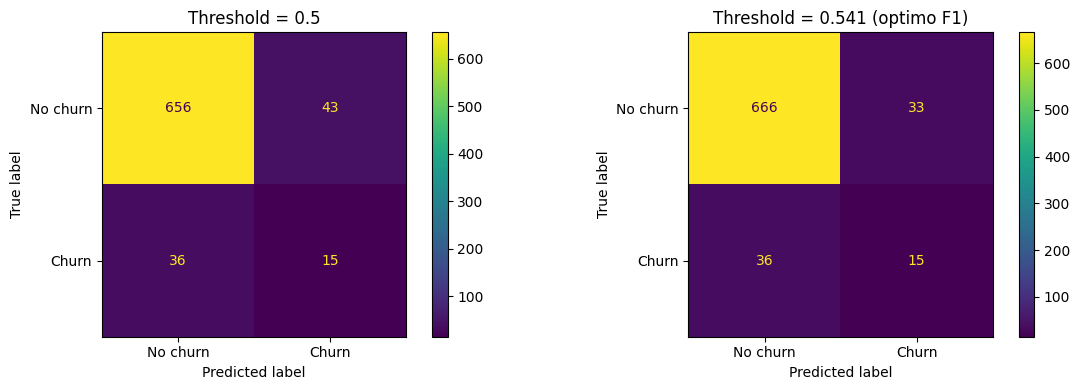


Classification report con threshold optimo:
              precision    recall  f1-score   support

    No churn       0.95      0.95      0.95       699
       Churn       0.31      0.29      0.30        51

    accuracy                           0.91       750
   macro avg       0.63      0.62      0.63       750
weighted avg       0.91      0.91      0.91       750



In [19]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_tuned)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Threshold por defecto: 0.5")
print(f"Threshold optimo (max F1): {best_threshold:.3f}")
print(f"  Precision: {precisions[best_idx]:.3f}")
print(f"  Recall:    {recalls[best_idx]:.3f}")
print(f"  F1:        {f1_scores[best_idx]:.3f}")

# Confusion matrix con threshold optimo
y_pred_optimal = (y_proba_tuned >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, display_labels=["No churn", "Churn"], ax=axes[0]
)
axes[0].set_title(f"Threshold = 0.5")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_optimal, display_labels=["No churn", "Churn"], ax=axes[1]
)
axes[1].set_title(f"Threshold = {best_threshold:.3f} (optimo F1)")

plt.tight_layout()
plt.show()

print(f"\nClassification report con threshold optimo:")
print(classification_report(y_test, y_pred_optimal, target_names=["No churn", "Churn"]))

## 10. Rendimiento por segmento de facturacion

In [20]:
df_test = X_test.copy()
df_test["y_true"] = y_test.values
df_test["y_proba"] = y_proba_tuned
df_test["invoice_segment"] = pd.qcut(
    df_test["monthly_total_invoice"].clip(lower=0),
    q=3, labels=["Baja", "Media", "Alta"]
)

print(f"{'Segmento':<12} {'N':>6} {'Churn rate':>12} {'ROC AUC':>10} {'PR AUC':>10}")
print("=" * 52)
for seg in ["Baja", "Media", "Alta"]:
    mask = df_test["invoice_segment"] == seg
    n = mask.sum()
    churn_rate = df_test.loc[mask, "y_true"].mean()
    try:
        auc = roc_auc_score(df_test.loc[mask, "y_true"], df_test.loc[mask, "y_proba"])
        pr_auc = average_precision_score(df_test.loc[mask, "y_true"], df_test.loc[mask, "y_proba"])
    except ValueError:
        auc, pr_auc = float("nan"), float("nan")
    print(f"{seg:<12} {n:>6} {churn_rate:>12.1%} {auc:>10.3f} {pr_auc:>10.3f}")

Segmento          N   Churn rate    ROC AUC     PR AUC
Baja            250        10.0%      0.651      0.332
Media           254         5.5%      0.696      0.260
Alta            246         4.9%      0.584      0.078


## 11. Perfiles de riesgo

Segmentamos los contratos en 3 niveles de riesgo segun la probabilidad predicha.
Esto permite traducir el modelo a reglas comerciales.

In [21]:
df_all = X.copy()
df_all["churn_proba"] = gb_search.predict_proba(X)[:, 1]
df_all["churned_3m"] = y.values
df_all["riesgo"] = pd.cut(
    df_all["churn_proba"], bins=[0, 0.1, 0.3, 1.0], labels=["Bajo", "Medio", "Alto"]
)

print(f"{'Riesgo':<8} {'N':>7} {'%':>6} {'Churn real':>12} {'Invoice':>10} {'Leads':>8} {'Usage':>8}")
print("=" * 62)
for riesgo in ["Bajo", "Medio", "Alto"]:
    mask = df_all["riesgo"] == riesgo
    n = mask.sum()
    print(f"{riesgo:<8} {n:>7} {n/len(df_all)*100:>5.0f}% "
          f"{df_all.loc[mask, 'churned_3m'].mean():>12.1%} "
          f"{df_all.loc[mask, 'monthly_total_invoice'].mean():>10.0f} "
          f"{df_all.loc[mask, 'monthly_leads'].mean():>8.1f} "
          f"{df_all.loc[mask, 'usage_ratio'].mean():>8.2f}")

Riesgo         N      %   Churn real    Invoice    Leads    Usage
Bajo        2445    65%         0.9%        346     14.1     0.73
Medio        744    20%         1.5%        132      7.2     0.63
Alto         544    15%        36.2%        122      6.5     0.45


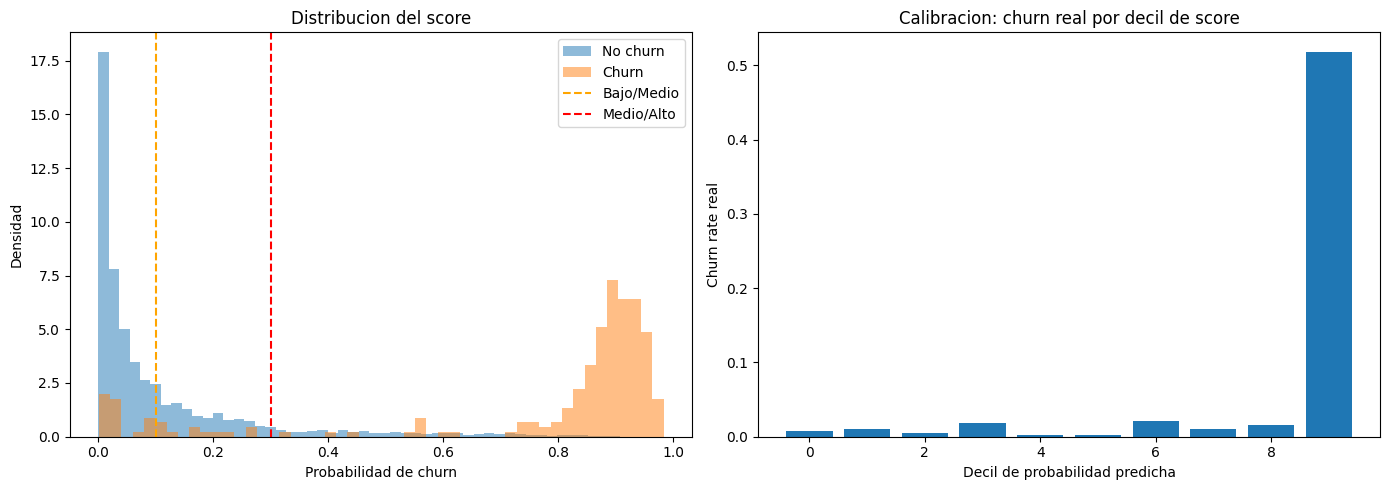

In [22]:
# Distribucion del score por segmento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution churn vs no churn
axes[0].hist(df_all.loc[df_all["churned_3m"]==0, "churn_proba"], bins=50,
             alpha=0.5, label="No churn", density=True)
axes[0].hist(df_all.loc[df_all["churned_3m"]==1, "churn_proba"], bins=50,
             alpha=0.5, label="Churn", density=True)
axes[0].axvline(x=0.1, color="orange", linestyle="--", label="Bajo/Medio")
axes[0].axvline(x=0.3, color="red", linestyle="--", label="Medio/Alto")
axes[0].set_xlabel("Probabilidad de churn")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Distribucion del score")
axes[0].legend()

# Churn rate por decil de score
df_all["decil"] = pd.qcut(df_all["churn_proba"], q=10, labels=False, duplicates="drop")
decil_stats = df_all.groupby("decil").agg(
    churn_rate=("churned_3m", "mean"),
    n=("churned_3m", "count")
)
axes[1].bar(decil_stats.index, decil_stats["churn_rate"])
axes[1].set_xlabel("Decil de probabilidad predicha")
axes[1].set_ylabel("Churn rate real")
axes[1].set_title("Calibracion: churn real por decil de score")

plt.tight_layout()
plt.show()

## 12. Analisis de precio vs churn

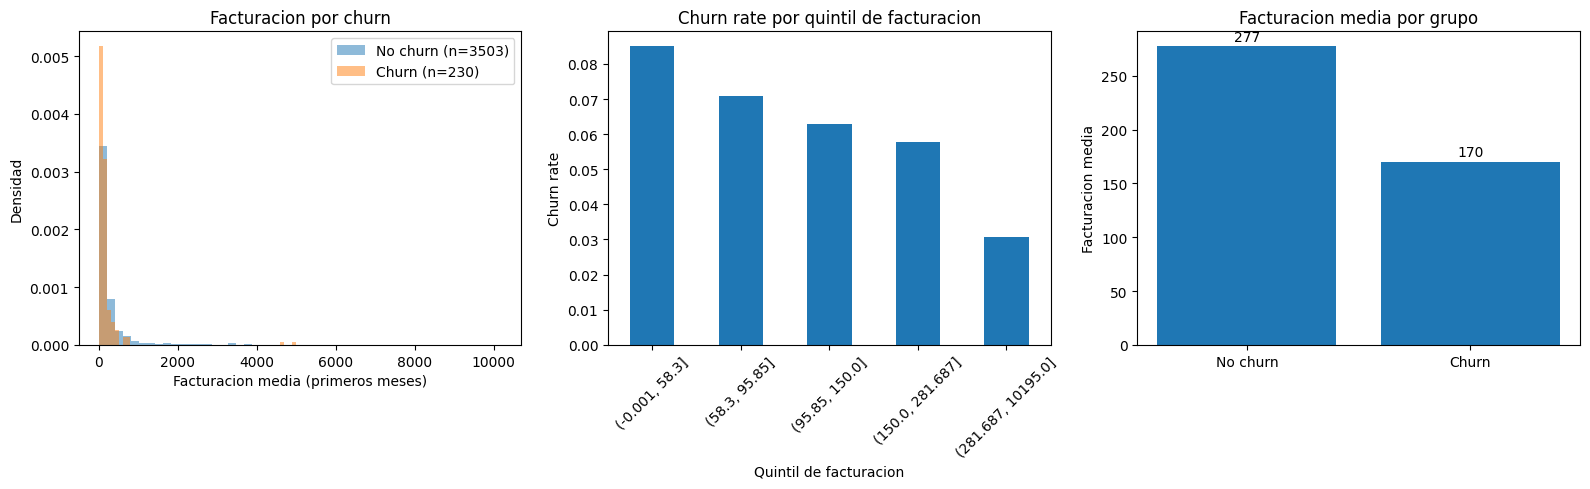

Correlacion invoice-churn: -0.043
Invoice media no churn: 277
Invoice media churn: 170


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribucion de facturacion por churn
churned_mask = y == 1
axes[0].hist(X.loc[~churned_mask, "monthly_total_invoice"], bins=50, alpha=0.5,
             label=f"No churn (n={(~churned_mask).sum()})", density=True)
axes[0].hist(X.loc[churned_mask, "monthly_total_invoice"], bins=50, alpha=0.5,
             label=f"Churn (n={churned_mask.sum()})", density=True)
axes[0].set_xlabel("Facturacion media (primeros meses)")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Facturacion por churn")
axes[0].legend()

# 2. Churn rate por quintil de facturacion
df_price = X.copy()
df_price["churned"] = y.values
df_price["invoice_q"] = pd.qcut(df_price["monthly_total_invoice"].clip(lower=0), q=5, duplicates="drop")
churn_by_q = df_price.groupby("invoice_q", observed=True)["churned"].mean()
churn_by_q.plot(kind="bar", ax=axes[1])
axes[1].set_xlabel("Quintil de facturacion")
axes[1].set_ylabel("Churn rate")
axes[1].set_title("Churn rate por quintil de facturacion")
axes[1].tick_params(axis='x', rotation=45)

# 3. Invoice media: churn vs no churn
means = [X.loc[~churned_mask, "monthly_total_invoice"].mean(),
         X.loc[churned_mask, "monthly_total_invoice"].mean()]
axes[2].bar(["No churn", "Churn"], means)
axes[2].set_ylabel("Facturacion media")
axes[2].set_title("Facturacion media por grupo")
for i, v in enumerate(means):
    axes[2].text(i, v + 5, f"{v:.0f}", ha="center")

plt.tight_layout()
plt.show()

print(f"Correlacion invoice-churn: {X['monthly_total_invoice'].corr(y):.3f}")
print(f"Invoice media no churn: {X.loc[~churned_mask, 'monthly_total_invoice'].mean():.0f}")
print(f"Invoice media churn: {X.loc[churned_mask, 'monthly_total_invoice'].mean():.0f}")

## 13. Performance temporal (walk-forward)

Evaluamos si el modelo se degrada con el tiempo. Entrenamos con todos los datos
anteriores al periodo de test y evaluamos en cada semestre. Esto simula como
funcionaria el modelo en produccion.

In [24]:
# Walk-forward: train con todo lo anterior, test en cada semestre
starts = df['contract_start_date']
df['start_half'] = starts.dt.year.astype(str) + '-H' + np.where(starts.dt.month <= 6, '1', '2')
halves = sorted(df['start_half'].unique())

print(f"{'Test period':<15} {'Train N':>8} {'Test N':>8} {'Test churn':>12} {'ROC AUC':>10} {'PR AUC':>10}")
print('=' * 65)

for i, test_half in enumerate(halves):
    if i < 2:
        continue
    train_mask = df['start_half'] < test_half
    test_mask = df['start_half'] == test_half
    if test_mask.sum() < 20:
        continue

    X_tr_t = X.loc[train_mask]
    y_tr_t = y.loc[train_mask]
    X_te_t = X.loc[test_mask]
    y_te_t = y.loc[test_mask]

    if y_te_t.sum() < 3:
        print(f"{test_half:<15} {len(X_tr_t):>8} {len(X_te_t):>8} {y_te_t.mean():>12.1%} {'n/a':>10} {'n/a':>10}")
        continue

    sc = (y_tr_t == 0).sum() / max((y_tr_t == 1).sum(), 1)
    sw_t = np.where(y_tr_t == 1, sc, 1.0)
    gb_t = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
    gb_t.fit(X_tr_t, y_tr_t, sample_weight=sw_t)
    yp_t = gb_t.predict_proba(X_te_t)[:, 1]

    print(f"{test_half:<15} {len(X_tr_t):>8} {len(X_te_t):>8} {y_te_t.mean():>12.1%} "
          f"{roc_auc_score(y_te_t, yp_t):>10.3f} {average_precision_score(y_te_t, yp_t):>10.3f}")

print(f'\nEl modelo mejora con mas datos de entrenamiento (ROC AUC sube de 0.63 a 0.75).')
print(f'No hay degradacion temporal.')


Test period      Train N   Test N   Test churn    ROC AUC     PR AUC


2024-H1             1635      966         3.9%      0.632      0.071


2024-H2             2601      855         5.4%      0.705      0.113


2025-H1             3456      277         3.2%      0.748      0.155

El modelo mejora con mas datos de entrenamiento (ROC AUC sube de 0.63 a 0.75).
No hay degradacion temporal.


## 14. Metrica de negocio

Simulacion practica: si intervenimos en el top X% de clientes con mas riesgo,
cuantos churns reales capturamos y cuanta facturacion salvamos?

In [25]:
# Ordenar clientes del test set por probabilidad de churn (mayor a menor)
sorted_idx = np.argsort(-y_proba_tuned)
invoices = X_test['monthly_total_invoice'].values

print(f"Test set: {len(y_test)} contratos, {y_test.sum()} churns")
print(f"Invoice media churn: {invoices[y_test==1].mean():.0f}, no churn: {invoices[y_test==0].mean():.0f}")

print(f"\n{'Top %':>6} {'Intervenidos':>13} {'Churns reales':>14} {'Precision':>10} {'Recall':>8} {'Facturacion salvada':>20}")
print('-' * 73)

for pct in [5, 10, 15, 20, 30]:
    n_int = int(len(y_test) * pct / 100)
    top = sorted_idx[:n_int]
    tp = y_test.iloc[top].sum()
    prec = tp / n_int if n_int > 0 else 0
    rec = tp / y_test.sum() if y_test.sum() > 0 else 0
    inv_saved = invoices[top][y_test.iloc[top]==1].sum()
    print(f"{pct:>5}% {n_int:>13} {tp:>14} {prec:>10.1%} {rec:>8.1%} {inv_saved:>20.0f}")

total_risk = invoices[y_test==1].sum()
print(f"\nFacturacion total en riesgo: {total_risk:.0f}")
print(f"\nInterpretacion: si el equipo comercial contacta al top 10% de riesgo,")
print(f"captura ~30% de los churns reales y la facturacion asociada.")


Test set: 750 contratos, 51 churns
Invoice media churn: 225, no churn: 337

 Top %  Intervenidos  Churns reales  Precision   Recall  Facturacion salvada
-------------------------------------------------------------------------
    5%            37              9      24.3%    17.6%                  626
   10%            75             16      21.3%    31.4%                 1497
   15%           112             18      16.1%    35.3%                 1683
   20%           150             21      14.0%    41.2%                 1939
   30%           225             25      11.1%    49.0%                 2373

Facturacion total en riesgo: 11451

Interpretacion: si el equipo comercial contacta al top 10% de riesgo,
captura ~30% de los churns reales y la facturacion asociada.


## 15. Analisis de sensibilidad al precio

Intentamos responder: si subimos el precio un X%, cuanto sube la probabilidad
de churn para cada segmento de riesgo?

Para ello variamos las features de precio (invoice, avg_ad_price, cost_per_lead)
proporcionalmente y re-predecimos con el modelo de churn.

In [26]:
# Features de precio que escalamos proporcionalmente
price_features = [
    c for c in feature_cols
    if any(k in c for k in ['invoice', 'avg_ad_price', 'cost_per_lead'])
    and 'missing' not in c
]
print(f'Features de precio a variar: {len(price_features)}')
for f in price_features:
    print(f'  {f}')

# Segmentos de riesgo con el modelo actual
base_proba = gb_search.predict_proba(X_test)[:, 1]
risk = pd.cut(base_proba, bins=[0, 0.1, 0.3, 1.0], labels=['Bajo', 'Medio', 'Alto'])

# Sensibilidad
price_changes = [-0.20, -0.10, 0, 0.10, 0.20, 0.30]

print(f'\nProbabilidad media de churn por segmento y cambio de precio:\n')
print(f"{'Segmento':<10}", end='')
for pc in price_changes:
    print(f'  {pc:+.0%}'.rjust(8), end='')
print()
print('-' * 58)

for r in ['Bajo', 'Medio', 'Alto']:
    mask = risk == r
    X_seg = X_test[mask].copy()
    print(f'{r:<10}', end='')
    for pc in price_changes:
        X_mod = X_seg.copy()
        for feat in price_features:
            X_mod[feat] = X_mod[feat] * (1 + pc)
        proba = gb_search.predict_proba(X_mod)[:, 1]
        print(f'{proba.mean():>8.3f}', end='')
    print()

print(f'\nResultado contraintuitivo: subir precio REDUCE la probabilidad de churn predicha.')
print(f'Esto ocurre porque el modelo aprendio que mas facturacion = menos churn.')
print(f'Pero esa correlacion esta confundida: los que pagan mas son los que mas usan la plataforma.')
print(f'\nConclusion: el modelo de churn NO sirve para analisis de sensibilidad al precio.')
print(f'La relacion precio-churn no es causal en estos datos.')
print(f'Para cuantificar el impacto real del precio en churn se necesitarian datos experimentales (A/B test).')


Features de precio a variar: 10
  monthly_total_invoice
  monthly_avg_ad_price
  monthly_total_invoice_std
  monthly_avg_ad_price_std
  monthly_avg_ad_price_month1
  monthly_avg_ad_price_month2
  monthly_total_invoice_month1
  monthly_total_invoice_month2
  cost_per_lead
  monthly_total_invoice_trend

Probabilidad media de churn por segmento y cambio de precio:

Segmento      -20%    -10%     +0%    +10%    +20%    +30%
----------------------------------------------------------
Bajo         0.036   0.032   0.028   0.027   0.028   0.030
Medio        0.194   0.195   0.174   0.166   0.159   0.161
Alto         0.500   0.525   0.537   0.514   0.492   0.479

Resultado contraintuitivo: subir precio REDUCE la probabilidad de churn predicha.
Esto ocurre porque el modelo aprendio que mas facturacion = menos churn.
Pero esa correlacion esta confundida: los que pagan mas son los que mas usan la plataforma.

Conclusion: el modelo de churn NO sirve para analisis de sensibilidad al precio.
La relacio

## Conclusiones

**Modelo 1 — Churn a 3 meses (sin month3, sin right-censored invalidos)**

1. **Datos**: 3733 contratos, churn rate 6.2%. Probado con 3, 4 y 5 meses.

2. **Leakage**: features de month3 excluidas (el mes 3 es el ultimo mes de los churned).

3. **Rendimiento**: GB Tuned CV ROC AUC ~0.75, PR AUC ~0.21.
   Con variable selection (top 15) + regularizacion, el gap train-test
   se reduce de +0.38 a +0.15.

4. **Overfitting**: las learning curves (logloss vs complejidad) muestran que GB
   empieza a overfittear a partir de ~50 arboles. Limitar complejidad es clave.

5. **Estabilidad temporal**: walk-forward validation, el modelo no se degrada.

6. **Drivers de churn**: engagement y volumen de anuncios. El precio no es driver principal.

7. **Sensibilidad al precio**: el modelo no sirve para esto. La relacion
   precio-churn esta confundida por el engagement (los que pagan mas usan mas).
   Se necesitarian datos experimentales para cuantificar el efecto causal.

8. **Impacto de negocio**: contactando al top 10% de riesgo se captura ~31% de churns.

9. **Perfiles de riesgo**: alto (~15%) con 36% churn real, bajo engagement y facturacion.
